<a href="https://colab.research.google.com/github/panditsumit8825/Machine-Learning/blob/main/end_to_end_ml.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd

In [ ]:
df=pd.read_csv('/content/placement.csv')

In [ ]:
df.head()

,Unnamed: 0,cgpa,iq,placement
0,0,6.8,123.0,1
1,1,5.9,106.0,0
2,2,5.3,121.0,0
3,3,7.4,132.0,1
4,4,5.8,142.0,0


In [ ]:
df.shape

(100, 4)

In [ ]:
# Steps
# 0. preprocess +eda + featureSelectin
# 1. extract input and output cols
# 2. scale the value
# 3. train test split
# 4. train the model
# 5. evaluate the model/model selection
# 6. deploy the model


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   cgpa       100 non-null    float64
 1   iq         100 non-null    float64
 2   placement  100 non-null    int64  
dtypes: float64(2), int64(1)
memory usage: 2.5 KB


In [ ]:
df=df.iloc[:,1:]

In [ ]:
df.head()

,cgpa,iq,placement
0,6.8,123.0,1
1,5.9,106.0,0
2,5.3,121.0,0
3,7.4,132.0,1
4,5.8,142.0,0


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

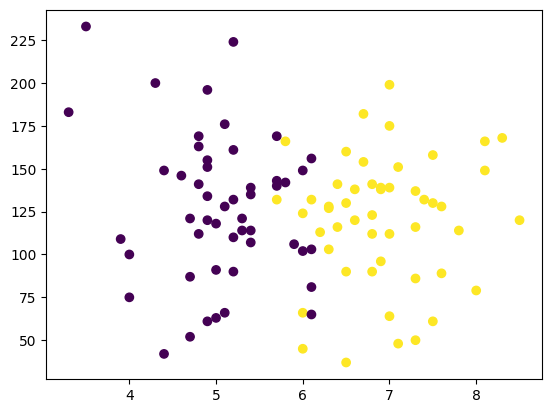

In [ ]:
plt.scatter(df['cgpa'],df['iq'],c=df['placement'])

In [ ]:
x=df.iloc[:,0:2]
y=df.iloc[:,-1:]


In [ ]:
x

,cgpa,iq
0,6.8,123.0
1,5.9,106.0
2,5.3,121.0
3,7.4,132.0
4,5.8,142.0
...,...,...
95,4.3,200.0
96,4.4,42.0
97,6.7,182.0
98,6.3,103.0


In [ ]:
y

,placement
0,1
1,0
2,0
3,1
4,0
...,...
95,0
96,0
97,1
98,1


In [ ]:
# step 4
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.1)

In [ ]:
x_train

,cgpa,iq
65,8.1,166.0
38,6.5,160.0
84,5.7,169.0
48,6.6,138.0
26,7.0,199.0
...,...,...
67,5.0,118.0
53,8.3,168.0
99,6.2,113.0
77,7.3,50.0


In [ ]:
x_test

,cgpa,iq
71,6.1,132.0
27,6.0,124.0
5,7.1,48.0
9,5.1,66.0
66,6.9,96.0
58,8.0,79.0
60,6.9,139.0
23,4.7,87.0
89,4.9,151.0
52,7.0,175.0


In [ ]:
# step 3
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
x_train=scaler.fit_transform(x_train)
x_test=scaler.transform(x_test)

In [ ]:
x_train

array([[ 1.87055187,  1.03303135],
       [ 0.47200842,  0.88140402],
       [-0.22726331,  1.10884501],
       [ 0.55941738,  0.32543717],
       [ 0.90905325,  1.86698164],
       [ 0.03496359, -2.02478637],
       [-1.01394401, -0.33161458],
       [ 0.90905325, -0.33161458],
       [-0.66430814, -0.38215702],
       [-1.10135297, -1.84788783],
       [-0.57689918, -0.10417359],
       [ 0.12237255, -1.11502242],
       [ 0.38459945, -0.23052969],
       [-0.92653504, -1.62044684],
       [ 0.29719048, -0.55905556],
       [ 1.25868911,  0.17380984],
       [-1.36357987, -2.10060003],
       [ 1.17128015,  0.30016595],
       [-0.22726331,  0.45179327],
       [ 1.34609808,  0.1232674 ],
       [ 0.47200842, -2.22695614],
       [ 1.43350704, -0.91285265],
       [-0.92653504,  0.22435228],
       [-0.22726331,  0.37597961],
       [ 0.03496359, -1.49409073],
       [ 0.47200842,  0.1232674 ],
       [-0.92653504, -0.12944481],
       [-0.92653504,  0.75504792],
       [ 1.34609808,

In [ ]:
x_test

array([[ 0.12237255,  0.17380984],
       [ 0.03496359, -0.02835993],
       [ 0.99646221, -1.94897271],
       [-0.75171711, -1.49409073],
       [ 0.82164428, -0.73595411],
       [ 1.78314291, -1.16556486],
       [ 0.82164428,  0.35070839],
       [-1.10135297, -0.9633951 ],
       [-0.92653504,  0.65396304],
       [ 0.90905325,  1.26047234]])

In [ ]:
# step 5
from sklearn.linear_model import LogisticRegression
clf=LogisticRegression()
# model training
clf.fit(x_train,y_train)

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


LogisticRegression()

In [ ]:
y_pred=clf.predict(x_test)

In [ ]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_pred)

0.9

In [ ]:
y_test

,placement
71,1
27,1
5,1
9,0
66,1
58,1
60,1
23,0
89,0
52,1


In [ ]:
# step 6
from mlxtend.plotting import plot_decision_regions

<Axes: >

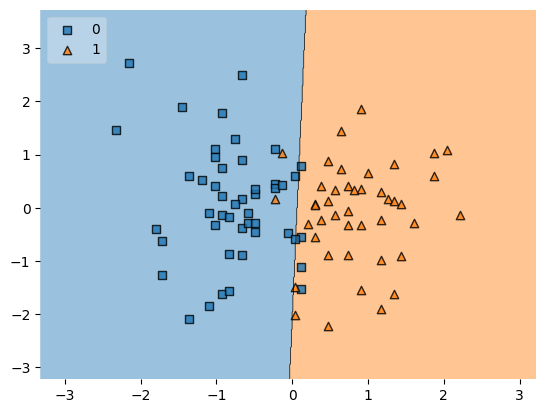

In [ ]:
plot_decision_regions(x_train, y_train.values.ravel(), clf=clf, legend=2)

In [ ]:
# step 7
import pickle

In [ ]:
pickle.dump(clf,open('model.pkl','wb'))

# Day 15
### Working with csv files

### 3.Opening a csv file from an URL

In [ ]:
import pandas as pd

### Opening csv file by an URL

In [ ]:
import requests
from io import StringIO
url="https://github.com/anhquan0412/dataset/blob/main/aug_train.csv"
headres={"User-Agent":"Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/114.0.0.0 Safari/537.36"}
req=requests.get(url,headers=headres)
data=StringIO(req.text)
pd.read_csv(data)

ParserError: Error tokenizing data. C error: Expected 1 fields in line 28, saw 9


## JSON/SQL

In [ ]:
# sql

!pip install mysql.connector

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.9/11.9 MB 45.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for mysql.connector: filename=mysql_connector-2.2.9-cp313-cp313-linux_x86_64.whl size=248031 sha256=2359c148924709991b58ade1072efd5047f13c84168e522b60c31e10be4d7260
  Stored in directory: /root/.cache/pip/wheels/4e/c1/23/9423c444a75266a05275c80ebf5c6efe2368388e976b690a0f
Successfully built mysql.connector


In [ ]:
import mysql.connector

In [ ]:
# conn = mysql.connector.connect(host='localhost',user='root',password='',database='world')

InterfaceError: 2003: Can't connect to MySQL server on 'localhost:3306' (111 Connection refused)

### Setting up MySQL Server in Colab

Google Colab environments do not come with a MySQL server pre-installed or running. You need to install it and configure it within your Colab session. These steps will set up a local MySQL server that you can connect to.

First, let's install MySQL server.

In [ ]:
!
# Install MySQL server
!apt-get update
!apt-get install -y mysql-server

# Start the MySQL service
!service mysql start

Next, we'll set a root password for MySQL. For simplicity in Colab, we can set an empty password or a known one. I'll set an empty password for `root` user to match your previous connection attempt, but in a real-world scenario, you should always use a strong password.

In [ ]:
# Set root password to empty (for Colab convenience, not recommended for production)
!mysql -e "ALTER USER 'root'@'localhost' IDENTIFIED WITH mysql_native_password BY '';"
!mysql -e "FLUSH PRIVILEGES;"

/bin/bash: line 1: mysql: command not found
/bin/bash: line 1: mysql: command not found


Now, let's create the 'world' database, as your original query was trying to access it. You can replace 'world' with any database name you wish.

In [ ]:
# Create the 'world' database
!mysql -e "CREATE DATABASE IF NOT EXISTS world;"

/bin/bash: line 1: mysql: command not found


With the server running and the database created, you can now connect to it using `mysql.connector`. The connection details (`host='localhost'`, `user='root'`, `password=''`, `database='world'`) should now work.

In [ ]:
import mysql.connector

try:
    conn = mysql.connector.connect(host='localhost', user='root', password='', database='world')
    if conn.is_connected():
        print('Successfully connected to MySQL database!')
        # You can now proceed with your SQL queries
        cursor = conn.cursor()
        cursor.execute("SHOW TABLES;") # Example query
        tables = cursor.fetchall()
        print("Tables in 'world' database:", tables)
    else:
        print('Failed to connect to MySQL database.')
except mysql.connector.Error as err:
    print(f"Error: {err}")
finally:
    if 'conn' in locals() and conn.is_connected():
        conn.close()
        print('MySQL connection closed.')

Error: 2003: Can't connect to MySQL server on 'localhost:3306' (111 Connection refused)


In [ ]:
pd.read_sql_query("SELECT * FROM city WHERE CountryCode LIKE 'IND'",conn)

NameError: name 'conn' is not defined

# Day -19
## Understanding your data

In [ ]:
import pandas as pd

In [ ]:
df=pd.read_csv('/content/Titanic-Dataset.csv')

In [ ]:
df.shape

(891, 12)

In [ ]:
# df.head(5)
df.sample(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
148,149,0,2,"Navratil, Mr. Michel (""Louis M Hoffman"")",male,36.50,0,2,230080,26.0000,F2,S
78,79,1,2,"Caldwell, Master. Alden Gates",male,0.83,0,2,248738,29.0000,NaN,S
231,232,0,3,"Larsson, Mr. Bengt Edvin",male,29.00,0,0,347067,7.7750,NaN,S
34,35,0,1,"Meyer, Mr. Edgar Joseph",male,28.00,1,0,PC 17604,82.1708,NaN,C
552,553,0,3,"O'Brien, Mr. Timothy",male,NaN,0,0,330979,7.8292,NaN,Q


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [ ]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [ ]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
# df.corr()['Survived'] bcz contain some string then not convert int
df.corr(numeric_only=True)['Survived']

,Survived
PassengerId,-0.005007
Survived,1.000000
Pclass,-0.338481
Age,-0.077221
SibSp,-0.035322
Parch,0.081629
Fare,0.257307


# Day - 20
## EDA

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
df=pd.read_csv('/content/Titanic-Dataset.csv')
df.head(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
print(df['Survived'].head())

0    0
1    1
2    1
3    1
4    0
Name: Survived, dtype: int64


#### 1. Categorical data
##### a. Countplot

,count
Survived,
0,549
1,342


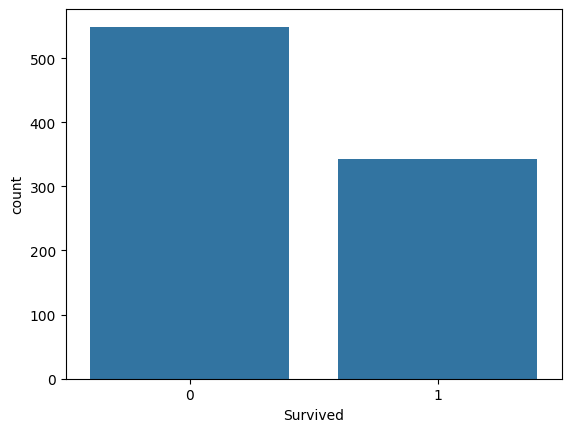

In [ ]:
sns.countplot(data=df , x='Survived')
df['Survived'].value_counts()

<Axes: xlabel='Pclass', ylabel='count'>

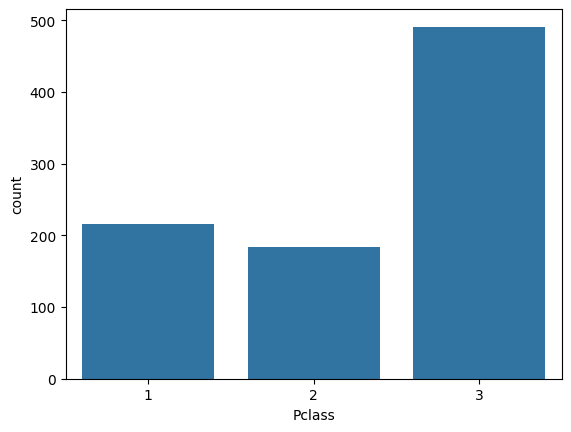

In [ ]:
sns.countplot(data=df,x='Pclass')

<Axes: xlabel='Sex', ylabel='count'>

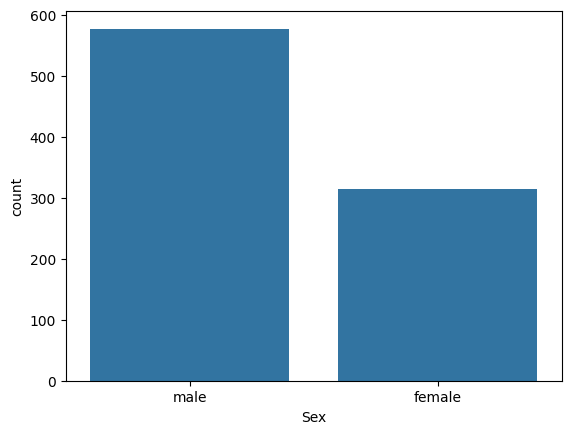

In [ ]:
sns.countplot(data=df,x='Sex')

<Axes: ylabel='count'>

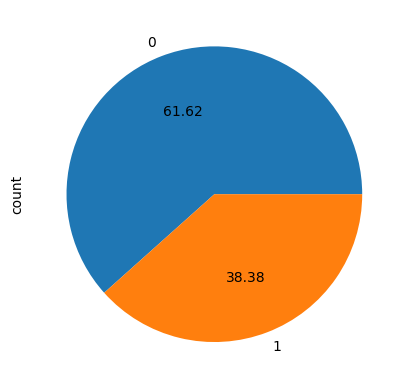

In [ ]:
df['Survived'].value_counts().plot(kind='pie',autopct='%.2f')

##### 2. Numerical data
##### a.Histogram

(array([40., 14., 15., 31., 79., 98., 85., 84., 73., 45., 35., 35., 29.,
        16., 13., 11.,  4.,  5.,  1.,  1.]),
 array([ 0.42 ,  4.399,  8.378, 12.357, 16.336, 20.315, 24.294, 28.273,
        32.252, 36.231, 40.21 , 44.189, 48.168, 52.147, 56.126, 60.105,
        64.084, 68.063, 72.042, 76.021, 80.   ]),
 <BarContainer object of 20 artists>)

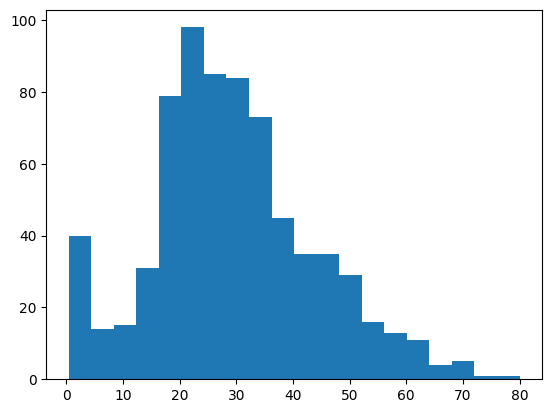

In [ ]:
import matplotlib.pyplot as plt
plt.hist(df['Age'],bins=20)

##### b. Distplot

/tmp/ipykernel_1545/3255828239.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['Age'])


<Axes: xlabel='Age', ylabel='Density'>

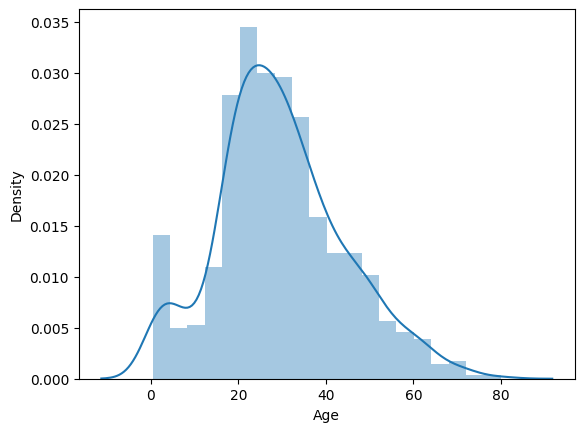

In [ ]:
sns.distplot(df['Age'])

##### c. Boxplot

<Axes: ylabel='Fare'>

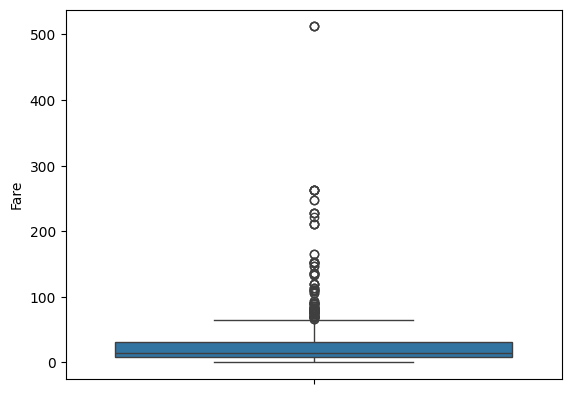

In [ ]:
sns.boxplot(df['Fare'])

<Axes: ylabel='Age'>

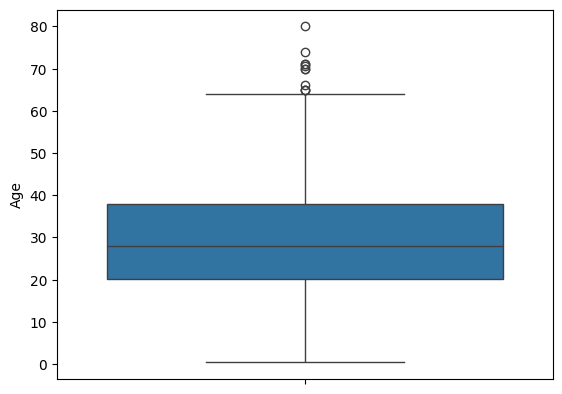

In [ ]:
sns.boxplot(df['Age'])

In [ ]:
df['Age'].min()

0.42

In [ ]:
df['Age'].skew()

np.float64(0.38910778230082704)